Run hazard_sim_undergrounding.py first

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Load base model 
conn_base = sqlite3.connect("/Users/mmuralid/Documents/NREL-erad/hazard_sim_base_model_p49uhs11_1247_results.db")
c_base = conn_base.cursor()

# Find table name
c_base.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = c_base.fetchall()
table_name = tables[0][0]   

# Fetch survival probabilities
c_base.execute(f'SELECT survival_probability FROM {table_name}')
survival_prob_base = c_base.fetchall()
s_p_base = pd.DataFrame([round(sp[0], 2) for sp in survival_prob_base], columns=['survival_probability'])


In [3]:
# Load UG model 
conn_ug = sqlite3.connect("/Users/mmuralid/Documents/NREL-erad/hazard_sim_ug_p49uhs11_1247_results.db")
c_ug = conn_ug.cursor()
# Fetch survival probabilities
c_ug.execute(f'SELECT survival_probability FROM {table_name}')
survival_prob_ug = c_ug.fetchall()
s_p_ug = pd.DataFrame([round(sp[0], 2) for sp in survival_prob_ug], columns=['survival_probability'])

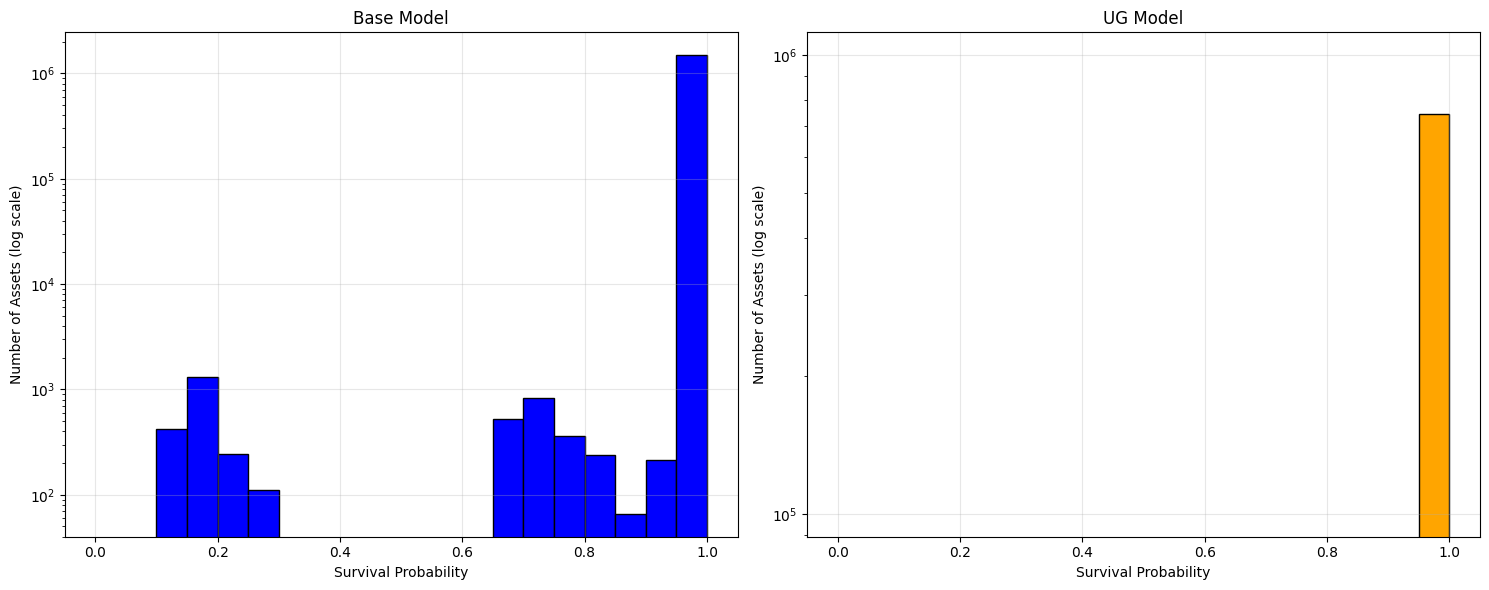

In [4]:
# Plot histograms side by side with log scale
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
bins = np.arange(0, 1.05, 0.05)

# Base Model
ax1.hist(s_p_base['survival_probability'], bins=bins, color='blue', edgecolor='black')
ax1.set_xlabel('Survival Probability')
ax1.set_ylabel('Number of Assets (log scale)')
ax1.set_title('Base Model')
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3)

# UG Model
ax2.hist(s_p_ug['survival_probability'], bins=bins, color='orange', edgecolor='black')
ax2.set_xlabel('Survival Probability')
ax2.set_ylabel('Number of Assets (log scale)')
ax2.set_title('UG Model')
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [5]:
# Fetch columns names in table
c_base.execute(f'PRAGMA table_info({table_name})')
columns_info = c_base.fetchall()
column_names = [col[1] for col in columns_info]
print(f"Columns in {table_name}: {column_names}")

# Print first 5 rows of the table
c_base.execute(f'SELECT * FROM {table_name} LIMIT 5')
first_five_rows = c_base.fetchall()
for row in first_five_rows:
    print(row)

Columns in assetstatetable: ['id', 'asset_name', 'asset_type', 'distribution_asset', 'timestamp', 'survival_probability', 'wind_speed__miles_per_hour', 'fire_boundary_dist__feet', 'flood_depth__feet', 'flood_velocity__feet_per_second', 'peak_ground_acceleration__feet_per_second2', 'peak_ground_velocity__inch_per_second']
(1, 'sb1_p49uhs11_1247_bus_1_2', 'distribution_poles', 'daba8f28-72ae-44c7-b263-8d0e7e7d99db', '1961-09-11T20:00:00', 1.0, 25.068569834748526, None, None, None, None, None)
(2, 'sb1_p49uhs11_1247_bus_1_2', 'distribution_poles', 'daba8f28-72ae-44c7-b263-8d0e7e7d99db', '1961-09-11T21:00:00', 1.0, 33.85281038776098, None, None, None, None, None)
(3, 'sb1_p49uhs11_1247_bus_1_2', 'distribution_poles', 'daba8f28-72ae-44c7-b263-8d0e7e7d99db', '1961-09-11T22:00:00', 1.0, 35.719552694769476, None, None, None, None, None)
(4, 'sb1_p49uhs11_1247_bus_1_2', 'distribution_poles', 'daba8f28-72ae-44c7-b263-8d0e7e7d99db', '1961-09-11T23:00:00', 1.0, 33.901862005507, None, None, None, N

In [6]:
# Find in c_base and c_ug with survival_probability less than 1.0
c_base.execute(f'SELECT * FROM {table_name} WHERE survival_probability < 1.0')
damaged_assets_base = c_base.fetchall()
damaged_assets_base = [row[:6] for row in damaged_assets_base]

c_ug.execute(f'SELECT * FROM {table_name} WHERE survival_probability < 1.0')
damaged_assets_ug = c_ug.fetchall()
damaged_assets_ug = [row[:6] for row in damaged_assets_ug]

# export to CSV
df_damaged_base = pd.DataFrame(damaged_assets_base, columns=column_names[:6])
df_damaged_ug = pd.DataFrame(damaged_assets_ug, columns=column_names[:6])
df_damaged_base.to_csv('damaged_assets_base_model.csv', index=False)
df_damaged_ug.to_csv('damaged_assets_ug_model.csv', index=False)

In [ ]:
# Close connections
conn_base.close()
conn_ug.close()